In [2]:
pip install mplsoccer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 3.9 MB/s eta 0:00:00
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_10_12_x86_64.whl (7.9 MB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_10_9_x86_64.whl (265 kB)
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.5.2
    Uninstalling matplotlib-3.5.2:
      Successfully uninstalled matplotlib-3.5.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pycaret 3.3.2 requires matplotlib<3.8.0, but you have matplotlib 3.9.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [1]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.image import imread
import requests
from io import BytesIO
from mplsoccer import VerticalPitch
import matplotlib.pyplot as plt
from PIL import Image
from neo4j import GraphDatabase
from mplsoccer import VerticalPitch
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv 
load_dotenv(dotenv_path = os.path.join(os.getcwd(),'config/.env'))
import os

In [2]:
print(os.getenv("NEO4J_PASSWORD"))

V2S2unBr-ex60KUDHFzMH_KLkiPggGUR9UkEZYreAPM


In [3]:

USER=os.getenv("NEO4J_USERNAME")

URI=os.getenv("NEO4J_URI")
PASSWORD = os.getenv("NEO4J_PASSWORD")
driver = GraphDatabase.driver(URI, auth=(USER, PASSWORD))

In [4]:
def visualise_team(defenders, midfielders, forwards):
    pitch = VerticalPitch(line_color='white', pitch_color='green' )
    fig, ax = pitch.draw(figsize=(16, 8))
    fig.patch.set_facecolor('green')
    def add_image_to_plot(ax, url, x, y):
        
        
        response = requests.get(url, timeout=5)
        if response.status_code == 200:
            img_data = BytesIO(response.content)
            img = Image.open(img_data)
            imagebox = OffsetImage(img, zoom=0.3)
            ab = AnnotationBbox(imagebox, (x, y), frameon=False)
            ax.add_artist(ab)
            print(f"Added image at ({x}, {y})")
        

    # Plot defenders
    for i, defender in enumerate(defenders):
        if i in {3,1}:
            ax.text( 15+ i * 20, 25, f"{defender['player']['name']}", fontsize=12, color='white', ha='center')
        else:
            ax.text( 10+ i * 23, 22.5, f"{defender['player']['name']}", fontsize=12, color='white', ha='center')
        
        x, y =  10+i * 22.5, 35
        add_image_to_plot(ax, defender['player']['img'], x, y)
        stat = defender["normalised_score"]
        ax.text(x + 10, y+5, f"{stat:.2f}", fontsize=10, color='yellow', ha='center', va='center')

    # Plot midfieldersx
    for i, midfielder in enumerate(midfielders):
        ax.text(i*35, 50 , f"{midfielder['player']['name']} ", fontsize=12, color='white')
        x, y = i * 35+5, 60
        add_image_to_plot(ax, midfielder['player']['img'], x, y)
        stat = midfielder["normalised_score"]
        ax.text(x + 10, y+5, f"{stat:.2f}", fontsize=10, color='yellow', ha='center', va='center')


    # Plot forwards
    for i, forward in enumerate(forwards):
        ax.text(i*35, 80, f"{forward['player']['name']} ", fontsize=12, color='white')
        x, y =  i * 35+5, 90
        add_image_to_plot(ax, forward['player']['img'], x, y)
        stat = forward["normalised_score"]
        ax.text(x + 10, y+5, f"{stat:.2f}", fontsize=10, color='yellow', ha='center', va='center')

    plt.title('Starting XI Visualization')
    plt.show()

In [20]:
find_highest_stat_oat('blocks')

/var/folders/78/b2j3spl172n6y7p_sw2jggr40000gn/T/ipykernel_56998/1582371114.py:12: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


9.0

In [19]:
def find_highest_stat_oat(stat):
    query="""
    MATCH (p:Player)-[stats:PLAYS_IN]-(m)-[:IS_OF_GW]->(gw)
    
    WHERE stats.{stat} IS NOT NULL 
    with p,m,
    AVG(stats.{stat}) as avg
    ORDER BY avg DESC
    LIMIT 1
    RETURN p.name,avg
    """
    with driver.session() as session:
        result = session.run(query.format(stat=stat))
        for record in result:
            return record['avg']

In [6]:
def find_highest_stat(stat,season):
    query=f"""
    MATCH (p:Player)-[stats:PLAYS_IN]-(m)-[:IS_OF_GW]->(gw)
    
    WHERE stats.{stat} IS NOT NULL AND gw.season = "{season}"
    with p,m,
    AVG(stats.{stat}) as avg
    ORDER BY avg DESC
    LIMIT 1
    RETURN p.name,avg
    """
    
    with driver.session() as session:
        result = session.run(query)
        for record in result:
            return record['avg']

plot for top team by stats

In [7]:
def visualise_team_v2(defenders, midfielders, forwards,query_stat):
    pitch = VerticalPitch(line_color='white', pitch_color='green' )
    fig, ax = pitch.draw(figsize=(16, 8))
    fig.patch.set_facecolor('green')
    def add_image_to_plot(ax, url, x, y):
        
        
        response = requests.get(url, timeout=5)
        if response.status_code == 200:
            img_data = BytesIO(response.content)
            img = Image.open(img_data)
            imagebox = OffsetImage(img, zoom=0.3)
            ab = AnnotationBbox(imagebox, (x, y), frameon=False)
            ax.add_artist(ab)
            
        

    # Plot defenders
    for i, defender in enumerate(defenders):
        if i in {3,1}:
            ax.text( 15+ i * 20, 25, f"{defender['player']['name']}", fontsize=12, color='white', ha='center')
        else:
            ax.text( 10+ i * 23, 22.5, f"{defender['player']['name']}", fontsize=12, color='white', ha='center')
        
        x, y =  10+i * 22.5, 35
        add_image_to_plot(ax, defender['player']['img'], x, y)
        ax.text(x + 10, y+5, f"{defender['avg_goals']:.2f}", fontsize=10, color='yellow', ha='center', va='center')
        

    # Plot midfieldersx
    for i, midfielder in enumerate(midfielders):
        ax.text(i*35, 50 , f"{midfielder['player']['name']} ", fontsize=12, color='white')
        x, y = i * 35+5, 60
        add_image_to_plot(ax, midfielder['player']['img'], x, y)
        ax.text(x + 10, y+5, f"{midfielder['avg_goals']:.2f}", fontsize=10, color='yellow', ha='center', va='center')
        


    # Plot forwards
    for i, forward in enumerate(forwards):
        ax.text(i*35, 80, f"{forward['player']['name']} ", fontsize=12, color='white')
        x, y =  i * 35+5, 90
        add_image_to_plot(ax, forward['player']['img'], x, y)
        ax.text(x + 10, y+5, f"{forward['avg_goals']:.2f}", fontsize=10, color='yellow', ha='center', va='center')
        
    title = 'Starting XI Greatest: '+ str(query_stat)
    plt.title(title)
    plt.show()

CHANGE WORDING TO BE FOR ANY STAT

In [8]:
import ipywidgets as widgets
from IPython.display import display
stat_options = [
    "goals", "assists", "penalties", "shots", "shots_on_target", "touches",
    "tackles", "interceptions", "blocks", "xg", "npxg", "xag", "sca", "gca",
    "passes_completed", "passes_attempted", "progressive_passes", "carries"
]
stat_dropdown = widgets.Dropdown(
    options=stat_options,
    value="goals",
    description="Stat:",
    style={'description_width': 'initial'}
)
season_dropdown = widgets.Dropdown(
    options=["2021-2022", "2022-2023", "2023-2024", "2024-2025"],  
    value="2024-2025",
    description="Season:",
    style={'description_width': 'initial'}
)



def get_top_team_by_stat(season, query_stat):
    query= f"""
    MATCH (def:Player)-[:IS_IN_SQUAD]->(squad:Squad)
    WHERE TOUPPER(def.position) CONTAINS "B" AND squad.name CONTAINS "{season}"
    AND def.img IS NOT NULL
    MATCH (def)-[stats:PLAYS_IN]-(m)-[:IS_OF_GW]-(gw)
    WHERE gw.season = "{season}"

    WITH def, AVG(stats.{query_stat}) AS avg_goals, def.img as img
    ORDER BY avg_goals DESC

    LIMIT 4

    WITH COLLECT(DISTINCT{{player: def, avg_goals: avg_goals, img: img}}) AS defenders,COLLECT(def.name) AS excluded_players

    MATCH (fw:Player)-[:IS_IN_SQUAD]->(squad:Squad)
    WHERE TOUPPER(fw.position) CONTAINS "W" AND squad.name CONTAINS "{season}"
    AND fw.img IS NOT NULL AND NOT fw.name IN excluded_players
    MATCH (fw)-[stats:PLAYS_IN]-(m)-[:IS_OF_GW]-(gw)
    WHERE gw.season = "{season}"

    WITH defenders, fw, AVG(stats.{query_stat}) AS avg_goals, fw.img as img
    ORDER BY avg_goals DESC
    LIMIT 3

    WITH defenders, COLLECT(DISTINCT{{player: fw, avg_goals: avg_goals, img: img}}) AS forwards,COLLECT(fw.name) AS excluded_players


    MATCH (mid:Player)-[:IS_IN_SQUAD]->(squad:Squad)
    WHERE TOUPPER(mid.position) CONTAINS "M" AND squad.name CONTAINS "{season}" 
    AND mid.img IS NOT NULL AND NOT mid.name IN excluded_players
    MATCH (mid)-[stats:PLAYS_IN]-(m)-[:IS_OF_GW]-(gw)
    WHERE gw.season = "{season}"

    WITH defenders,mid,forwards, AVG(stats.{query_stat}) AS avg_goals, mid.img as img
    ORDER BY avg_goals DESC
    LIMIT 3

    WITH defenders,forwards, COLLECT(DISTINCT{{player: mid, avg_goals: avg_goals, img: img}}) AS midfielders

    return defenders,midfielders,forwards
    """

    with driver.session() as session:
        result = session.run(query)
        for record in result:
                defenders = record['defenders']
                midfielders = record['midfielders']
                forwards = record['forwards']
                
                visualise_team_v2(defenders, midfielders, forwards,query_stat)
    driver.close()

widgets.interactive(get_top_team_by_stat, query_stat=stat_dropdown, season=season_dropdown)

interactive(children=(Dropdown(description='Season:', index=3, options=('2021-2022', '2022-2023', '2023-2024',…

/var/folders/78/b2j3spl172n6y7p_sw2jggr40000gn/T/ipykernel_56998/1435103110.py:13: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:
/var/folders/78/b2j3spl172n6y7p_sw2jggr40000gn/T/ipykernel_56998/541702879.py:156: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


Added image at (10.0, 35)
Added image at (32.5, 35)
Added image at (55.0, 35)
Added image at (77.5, 35)
Added image at (5, 60)
Added image at (40, 60)
Added image at (75, 60)
Added image at (5, 90)
Added image at (40, 90)
Added image at (75, 90)


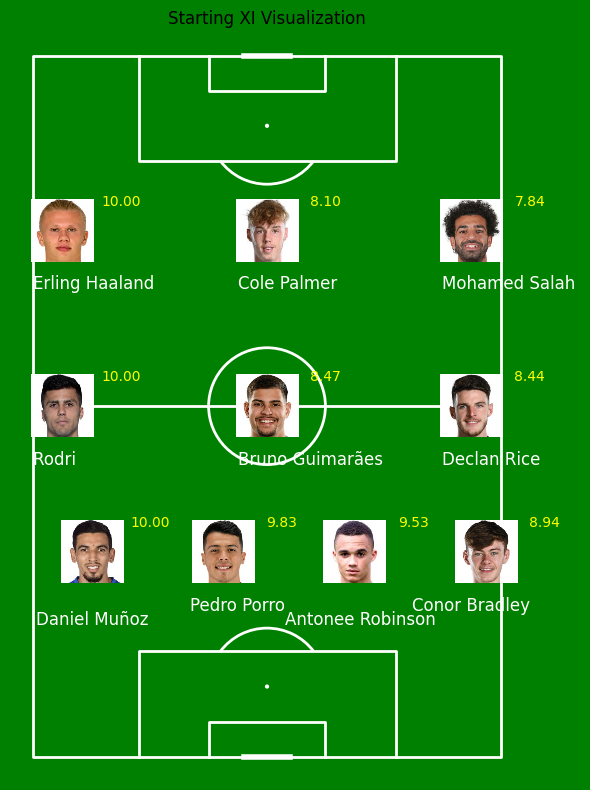

In [9]:

season = "2023-2024"
max_blocks=find_highest_stat("blocks",season)
max_shots=find_highest_stat("shots",season)
max_interceptions=find_highest_stat("interceptions",season)
max_tackles=find_highest_stat("tackles",season)
max_goals=find_highest_stat("goals",season)
max_assists=find_highest_stat("assists",season)
max_xg = find_highest_stat("xg",season)
max_carries = find_highest_stat("progressive_carries",season)
max_pass = find_highest_stat("progressive_passes",season)

query= f"""
MATCH (def:Player)-[:IS_IN_SQUAD]->(squad:Squad)
WHERE TOUPPER(def.position) CONTAINS "B" AND squad.name CONTAINS "{season}"
AND def.img IS NOT NULL
MATCH (def)-[stats:PLAYS_IN]-(m)-[:IS_OF_GW]-(gw)
WHERE gw.season = "{season}"

WITH def,
    
    AVG(stats.blocks) AS avg_blocks,
    AVG(stats.interceptions) AS avg_interceptions,
    AVG(stats.tackles) AS avg_tackles,
    AVG(stats.goals) AS avg_goals,
    AVG(stats.assists) AS avg_assists,
    AVG(stats.xg) as avg_xg,
    AVG(stats.progressive_carries) as avg_carries,
    AVG(stats.progressive_passes) as avg_pass,
    def.img as img

WITH def, img,
     0.2 * (avg_blocks / {max_blocks}) +
     0.2 * (avg_interceptions / {max_interceptions}) +
     0.2 * (avg_tackles  / {max_tackles} ) +
     0.05 * (avg_goals / {max_goals})+
     0.05 * (avg_assists/ {max_assists})+
     0.05 *(avg_xg/{max_xg})+
     0.05*(avg_carries/{max_carries})+
     0.2*(avg_pass/{max_pass})
     

AS raw_performance_score
ORDER BY raw_performance_score DESC

WITH COLLECT(DISTINCT{{player: def, performance: raw_performance_score, img: img}}) AS defenders,COLLECT(def.name) AS excluded_players,
MIN(raw_performance_score) AS min_def_score, 
     MAX(raw_performance_score) AS max_def_score

MATCH (fw:Player)-[:IS_IN_SQUAD]->(squad:Squad)
WHERE TOUPPER(fw.position) CONTAINS "W" AND squad.name CONTAINS "{season}" AND NOT fw.name IN excluded_players
MATCH (fw)-[stats:PLAYS_IN]-(m)-[:IS_OF_GW]-(gw)
WHERE gw.season = "{season}"

WITH fw, defenders,min_def_score, max_def_score,
    AVG(stats.goals) AS avg_goals,
    AVG(stats.assists) AS avg_assists,
    AVG(stats.xg) as avg_xg,
    AVG(stats.progressive_carries) as avg_carries,
    AVG(stats.progressive_passes) as avg_pass,
    AVG(stats.shots) as avg_shots


WITH defenders,fw,min_def_score, max_def_score,
     0.15*(avg_shots/{max_shots})+
     0.5 * (avg_goals / {max_goals})+
     0.1 * (avg_assists/ {max_assists})+
     0.175 *(avg_xg/{max_xg})+
     0.05*(avg_carries/{max_carries})+
     0.025*(avg_pass/{max_pass}) as raw_performance_score,
     fw.img AS img
ORDER BY raw_performance_score DESC

WITH defenders,min_def_score, max_def_score, COLLECT({{player: fw, performance:raw_performance_score, img: img}}) AS forwards,COLLECT(fw.name) AS excluded_players,
MIN(raw_performance_score) AS min_fw_score, 
     MAX(raw_performance_score) AS max_fw_score

MATCH (mid:Player)-[:IS_IN_SQUAD]->(squad:Squad)
WHERE TOUPPER(mid.position) CONTAINS "M" AND squad.name CONTAINS "{season}" AND NOT mid.name IN excluded_players
MATCH (mid)-[stats:PLAYS_IN]-(m)-[:IS_OF_GW]-(gw)
WHERE gw.season = "{season}"

with defenders, mid,forwards, min_def_score, max_def_score, min_fw_score, max_fw_score,
    AVG(stats.interceptions) AS avg_interceptions,
    AVG(stats.tackles) AS avg_tackles,
    AVG(stats.goals) AS avg_goals,
    AVG(stats.assists) AS avg_assists,
    AVG(stats.xg) as avg_xg,
    AVG(stats.progressive_carries) as avg_carries,
    AVG(stats.progressive_passes) as avg_pass,
    AVG(stats.shots) as avg_shots,
    mid.img as img
with defenders, mid, img,forwards, min_def_score, max_def_score, min_fw_score, max_fw_score,
     0.1*(avg_shots/{max_shots})+
     0.1 * (avg_interceptions / {max_interceptions}) +
     0.1 * (avg_tackles  / {max_tackles} ) +
     0.3 * (avg_goals / {max_goals})+
     0.1 * (avg_assists/ {max_assists})+
     0.1 *(avg_xg/{max_xg})+
     0.1*(avg_carries/{max_carries})+
     0.1*(avg_pass/{max_pass}) as raw_performance_score


ORDER BY raw_performance_score DESC


WITH defenders,forwards,min_def_score, max_def_score, min_fw_score, max_fw_score,  COLLECT({{player: mid, performance: raw_performance_score, img: img}}) AS midfielders,
MIN(raw_performance_score) AS min_mid_score,
     MAX(raw_performance_score) AS max_mid_score

     // Normalising score out of ten
WITH defenders, forwards, midfielders,
     min_def_score, max_def_score, 
     min_fw_score, max_fw_score, 
     min_mid_score, max_mid_score

UNWIND defenders AS def
WITH def, (def.performance - min_def_score) / (max_def_score - min_def_score) * 10 AS normalised_score,
     forwards, midfielders,
     min_fw_score, max_fw_score, 
     min_mid_score, max_mid_score
LIMIT 4
WITH COLLECT({{player: def.player, performance: def.performance, img: def.img, normalised_score: normalised_score}}) AS defenders,
     forwards, midfielders,
     min_fw_score, max_fw_score, 
     min_mid_score, max_mid_score
     


UNWIND forwards AS fw
WITH fw, (fw.performance - min_fw_score) / (max_fw_score - min_fw_score) * 10 AS normalised_score,
     defenders, midfielders,
     min_mid_score, max_mid_score
LIMIT 3
WITH defenders, COLLECT({{player: fw.player, performance: fw.performance, img: fw.img, normalised_score: normalised_score}}) AS forwards,
     midfielders, min_mid_score, max_mid_score


UNWIND midfielders AS mid
WITH mid, (mid.performance - min_mid_score) / (max_mid_score - min_mid_score) * 10 AS normalised_score,
     defenders, forwards
LIMIT 3
WITH defenders, forwards, COLLECT({{player: mid.player, performance: mid.performance, img: mid.img, normalised_score: normalised_score}}) AS midfielders

return defenders,midfielders,forwards


"""

with driver.session() as session:
    result = session.run(query)
    for record in result:
            defenders = record['defenders']
            midfielders = record['midfielders']
            forwards = record['forwards']
            visualise_team(defenders, midfielders, forwards)
driver.close()

In [10]:
import pandas as pd
max_blocks=find_highest_stat_oat("blocks")
max_shots=find_highest_stat_oat("shots")
max_interceptions=find_highest_stat_oat("interceptions")
max_tackles=find_highest_stat_oat("tackles")
max_goals=find_highest_stat_oat("goals")
max_assists=find_highest_stat_oat("assists")
max_xg = find_highest_stat_oat("xg")
max_carries = find_highest_stat_oat("progressive_carries")
max_pass = find_highest_stat_oat("progressive_passes")
query=f"""
WITH ["2021-2022", "2022-2023", "2023-2024", "2024-2025"] AS seasons

// Loops through every two season stopping at "2023-2024", "2024-2025"
UNWIND RANGE(0, SIZE(seasons) - 2) AS season_id
WITH seasons[season_id] AS season1, seasons[season_id + 1] AS season2

MATCH (def:Player)-[:IS_IN_SQUAD]->(squad:Squad)
WHERE TOUPPER(def.position) CONTAINS "B"

// Retrieving stats from previous and current season
MATCH (def)-[stats1:PLAYS_IN]->(m1:Match)-[:IS_OF_GW]->(gw1)
WHERE gw1.season = season1


MATCH (def)-[stats2:PLAYS_IN]-(m2:Match)-[:IS_OF_GW]-(gw2)
WHERE gw2.season = season2

// Calculating averages of all stats
WITH def, season1, season2,
AVG(stats1.blocks) AS avg_blocks1,
AVG(stats1.interceptions) AS avg_interceptions1,
AVG(stats1.tackles) AS avg_tackles1,
AVG(stats1.goals) AS avg_goals1,
AVG(stats1.assists) AS avg_assists1,
AVG(stats1.xg) as avg_xg1,
AVG(stats1.progressive_carries) as avg_carries1,
AVG(stats1.progressive_passes) as avg_pass1,
AVG(stats2.blocks) AS avg_blocks2,
AVG(stats2.interceptions) AS avg_interceptions2,
AVG(stats2.tackles) AS avg_tackles2,
AVG(stats2.goals) AS avg_goals2,
AVG(stats2.assists) AS avg_assists2,
AVG(stats2.xg) as avg_xg2,
AVG(stats2.progressive_carries) as avg_carries2,
AVG(stats2.progressive_passes) as avg_pass2

// Applying weighting for each stat, 
// This time using the best average stats of all time to weight in order to ensure comparibility
WITH def, season1, season2,
0.2 * (avg_blocks1 / {max_blocks}) +
0.2 * (avg_interceptions1 / {max_interceptions}) +
0.2 * (avg_tackles1  / {max_tackles}) +
0.05 * (avg_goals1 / {max_goals})+
0.05 * (avg_assists1/ {max_assists})+
0.05 *(avg_xg1/{max_xg})+
0.05*(avg_carries1/{max_carries})+
0.3*(avg_pass1/30) AS score_1,
0.2 * (avg_blocks2 /  {max_blocks}) +
0.2 * (avg_interceptions2 /  {max_interceptions}) +
0.2 * (avg_tackles2  / {max_tackles} ) +
0.05 * (avg_goals2 / {max_goals})+
0.05 * (avg_assists2/ {max_assists})+
0.05 *(avg_xg2/{max_xg})+
0.05*(avg_carries2/{max_carries})+
0.3*(avg_pass2/30) AS score_2

// Remove players with score_1 = 0 to avoid division by zero
WHERE score_1 > 0

WITH def, season1, season2, score_1, score_2, (score_2 - score_1)/score_1*100 AS growth

ORDER BY growth DESC

WITH def, season1, season2, score_1, score_2, growth
LIMIT 10

RETURN def.name AS player, season1, season2, score_1, score_2, growth
"""
growth_data = []
with driver.session() as session:
    result = session.run(query)
    for record in result:
            growth_data.append({"Player":record["player"],"Growth (%)":record["growth"],"Seasons":record["season1"]+"-->"+record["season2"]})
driver.close()
growth_df = pd.DataFrame(growth_data)


/var/folders/78/b2j3spl172n6y7p_sw2jggr40000gn/T/ipykernel_56998/3570172580.py:12: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:
/var/folders/78/b2j3spl172n6y7p_sw2jggr40000gn/T/ipykernel_56998/1485523030.py:81: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


In [77]:
growth_df

,Player,Growth (%),Seasons
0,Neco Williams,553.936818,2021-2022-->2022-2023
1,Tyrone Mings,323.102215,2023-2024-->2024-2025
2,Jamaal Lascelles,299.252562,2022-2023-->2023-2024
3,Matt Ritchie,243.040248,2022-2023-->2023-2024
4,Cody Drameh,143.478261,2021-2022-->2022-2023
5,Valentino Livramento,117.450442,2022-2023-->2023-2024
6,Ainsley Maitland-Niles,112.604352,2021-2022-->2022-2023
7,Jaïro Riedewald,111.791747,2022-2023-->2023-2024
8,Matt Doherty,101.780616,2023-2024-->2024-2025
9,Lisandro Martínez,98.736020,2023-2024-->2024-2025


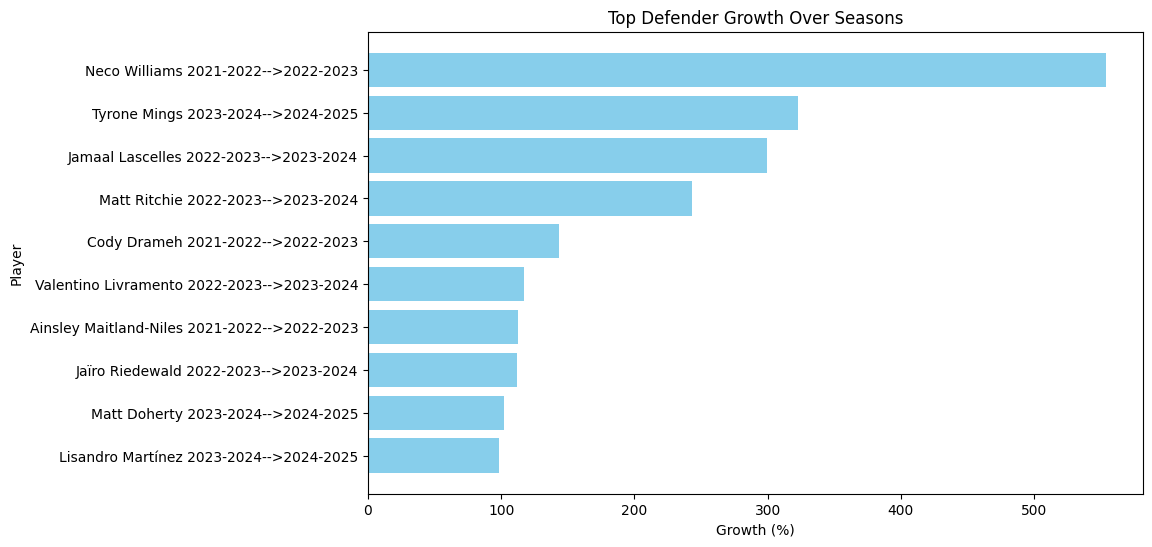

In [11]:

growth_df_sorted = growth_df.sort_values(by="Growth (%)", ascending=False)
plt.figure(figsize=(10, 6))
plt.barh((growth_df_sorted["Player"]+" "+growth_df_sorted["Seasons"]), growth_df_sorted["Growth (%)"], color='skyblue')
plt.xlabel("Growth (%)")
plt.ylabel("Player")
plt.title("Top Defender Growth Over Seasons")
plt.gca().invert_yaxis() 
plt.show()